Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load data
- The data exploration performed below concentrates on the data from July 2025 to June 2026.

In [18]:
files = [
    "data/CRMLSSold202507.csv",
    "data/CRMLSSold202508.csv",
    "data/CRMLSSold202509.csv",
    "data/CRMLSSold202510.csv",
    "data/CRMLSSold202511.csv",
    "data/CRMLSSold202512.csv",
    "data/CRMLSSold202601.csv",
    "data/CRMLSSold202602.csv",
    "data/CRMLSSold202603.csv",
    "data/CRMLSSold202604.csv",
    "data/CRMLSSold202605.csv",
    "data/CRMLSSold202606.csv",
]

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(df.shape)

/var/folders/tz/jmfckx6n1kb8sc7j2zzptcdm0000gn/T/ipykernel_5943/3896865759.py:16: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


(260293, 78)


In [19]:
df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,10000.0,509527617,nleimers@hotmail.com,...,NaN,5301.0,NaN,False,NaN,NaN,92325,0.0,5301.0,NaN
1,HighDesert,HighDesert,NaN,True,NaN,NaN,NaN,125000.0,507776532,rainmakerconlon@gmail.com,...,~331' x 119',39389.0,NaN,False,NaN,NaN,92345,NaN,39389.0,NaN
2,PacificWest,PacificWest,Laminate,False,NaN,NaN,False,2000.0,1120249676,cesarg@sevengables.com,...,NaN,124059.0,1.0,False,0.0,Tustin Unified,92701,NaN,124059.0,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,1040000.0,1120247618,agentsmylie@gmail.com,...,NaN,5318.0,NaN,False,2.0,NaN,92081,173.0,5318.0,NaN
4,PalmSprings,PalmSprings,"Carpet,Tile",True,NaN,NaN,True,2400000.0,1120245509,reagan.richter@compass.com,...,NaN,12632.0,NaN,False,2.0,NaN,92264,NaN,12632.0,NaN


Data Exploration

In [20]:
df["PropertyType"].value_counts()

PropertyType
Residential            174463
ResidentialLease        61197
Land                     7933
ResidentialIncome        7113
ManufacturedInPark       6597
CommercialSale           1582
CommercialLease          1262
BusinessOpportunity       146
Name: count, dtype: int64

In [21]:
df["PropertySubType"].value_counts()

PropertySubType
SingleFamilyResidence    159714
Condominium               44818
Townhouse                 14917
Apartment                  6725
Duplex                     5070
ManufacturedOnLand         2643
Triplex                    1740
Quadruplex                 1609
MixedUse                    895
StockCooperative            826
Office                      664
Retail                      437
Industrial                  265
Cabin                       242
Studio                      206
Business                    174
RoomingHouse                166
Warehouse                   129
MultiFamily                  68
SpecialPurpose               62
BoatSlip                     58
MobileHome                   50
OwnYourOwn                   39
WaterPositionWithLand        34
Loft                         34
Agriculture                  34
ManufacturedHome             30
UnimprovedLand               26
CoOwnership                   9
HotelMotel                    7
Timeshare               

The majority of property from 2025 july to 2026 june are primarily of residential and single family residence property type.

Filter Dataset

In [22]:
df_restricted = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
]
df_restricted.shape


(131377, 78)

In [23]:
df_restricted.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,1040000.0,1120247618,agentsmylie@gmail.com,...,NaN,5318.0,NaN,False,2.0,NaN,92081,173.0,5318.0,NaN
4,PalmSprings,PalmSprings,"Carpet,Tile",True,NaN,NaN,True,2400000.0,1120245509,reagan.richter@compass.com,...,NaN,12632.0,NaN,False,2.0,NaN,92264,NaN,12632.0,NaN
8,Mlslistings,Mlslistings,"Carpet,Laminate,Stone,Tile",True,NaN,NaN,NaN,NaN,1120239726,ed@carmelrealtycompany.com,...,NaN,3600.0,NaN,False,2.0,Other,93940,NaN,3600.0,NaN
9,PacificSouthwest,PacificSouthwest,NaN,True,NaN,NaN,False,1050000.0,1120231282,jared@clarkerealtors.com,...,NaN,17248.0,NaN,NaN,2.0,Escondido Union,92026,0.0,17248.0,NaN
10,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1120229958,miranda.bothe@gmail.com,...,NaN,10200.0,NaN,False,1.0,Other,94022,NaN,10200.0,NaN


Summary statistics

In [24]:
selected_cols = df_restricted[
    ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
]

selected_cols.describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,1.313770e+05,131313.000000,131377.000000,131369.000000,1.291240e+05
mean,1.339386e+06,2050.852786,3.495825,2.636246,3.934788e+05
std,7.842417e+06,1047.801835,0.963750,1.130969,1.805798e+07
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,6.250000e+05,1387.000000,3.000000,2.000000,5.663000e+03
50%,8.900000e+05,1821.000000,3.000000,2.000000,7.279000e+03
75%,1.420000e+06,2444.000000,4.000000,3.000000,1.045400e+04
max,9.895000e+08,56500.000000,22.000000,35.000000,1.938943e+09


In [25]:
# Examine appropriate bounds for ClosePrice
df_restricted["ClosePrice"].quantile([0, 0.1, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0])

0.00            0.0
0.10       440000.0
0.25       625000.0
0.50       890000.0
0.75      1420000.0
0.95      3178400.0
0.99      6400000.0
1.00    989500000.0
Name: ClosePrice, dtype: float64

In [26]:
# Examine appropriate bounds for LivingArea
df_restricted["LivingArea"].quantile([0, 0.1, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0])

0.00        0.0
0.10     1104.0
0.25     1387.0
0.50     1821.0
0.75     2444.0
0.95     3829.0
0.99     5692.0
1.00    56500.0
Name: LivingArea, dtype: float64

In [27]:
# Examine appropriate bounds for LotSize
df_restricted["LotSizeSquareFeet"].quantile([0, 0.1, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0])

0.00    0.000000e+00
0.10    4.250000e+03
0.25    5.663000e+03
0.50    7.279000e+03
0.75    1.045400e+04
0.95    5.096520e+04
0.99    2.765058e+05
1.00    1.938943e+09
Name: LotSizeSquareFeet, dtype: float64

First, a subset of the dataframe is created to focus on observations with values within the range where the majority (~99%) lie for ClosePrice, LivingArea, and LotSize. The cut offs are determined using the quantile information obtained above to help improve readability of the dsitribution plots.

In [28]:
# Limit range of values for ClosePrice, LivingArea, and LotSizeSquareFeet
df_filtered = df_restricted[
    (df_restricted["ClosePrice"] > 10000) & (df_restricted["ClosePrice"] < 6500000) &
    (df_restricted["LivingArea"] < 10000) & (df_restricted["LotSizeSquareFeet"] < 150000)
]

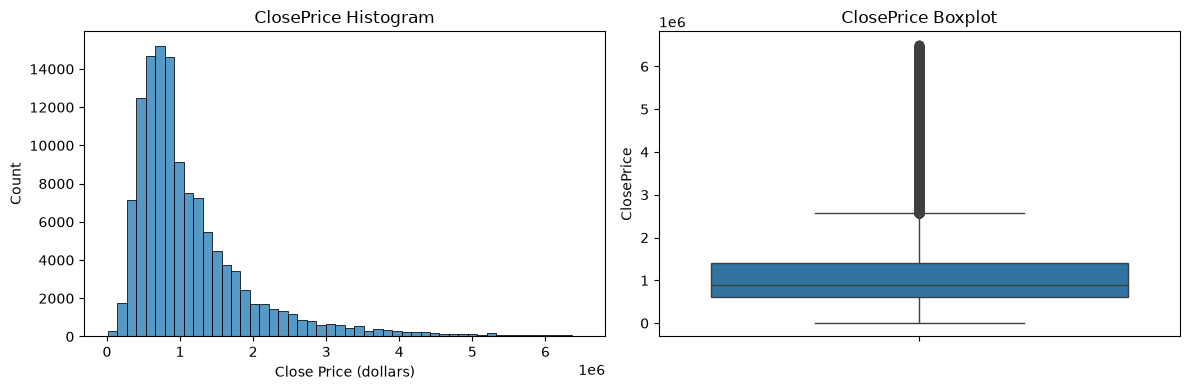

In [29]:
# ClosePrice
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df_filtered, x="ClosePrice", bins=50, ax=axes[0])
axes[0].set_title("ClosePrice Histogram")
axes[0].set_xlabel("Close Price (dollars)")

sns.boxplot(df_filtered["ClosePrice"].dropna(), ax=axes[1])
axes[1].set_title("ClosePrice Boxplot")

plt.tight_layout()
plt.show()

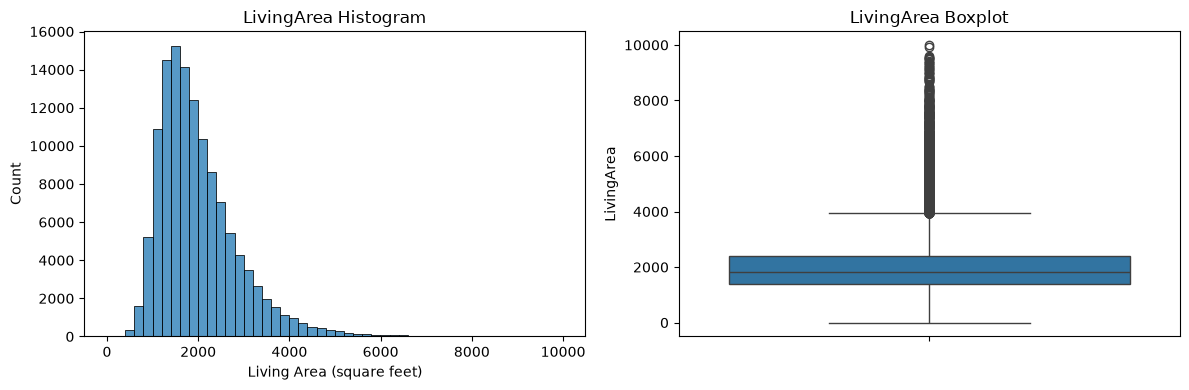

In [30]:
# LivingArea
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_filtered["LivingArea"].dropna(), bins=50, ax=axes[0])
axes[0].set_title("LivingArea Histogram")
axes[0].set_xlabel("Living Area (square feet)")

sns.boxplot(df_filtered["LivingArea"].dropna(), ax=axes[1])
axes[1].set_title("LivingArea Boxplot")

plt.tight_layout()
plt.show()

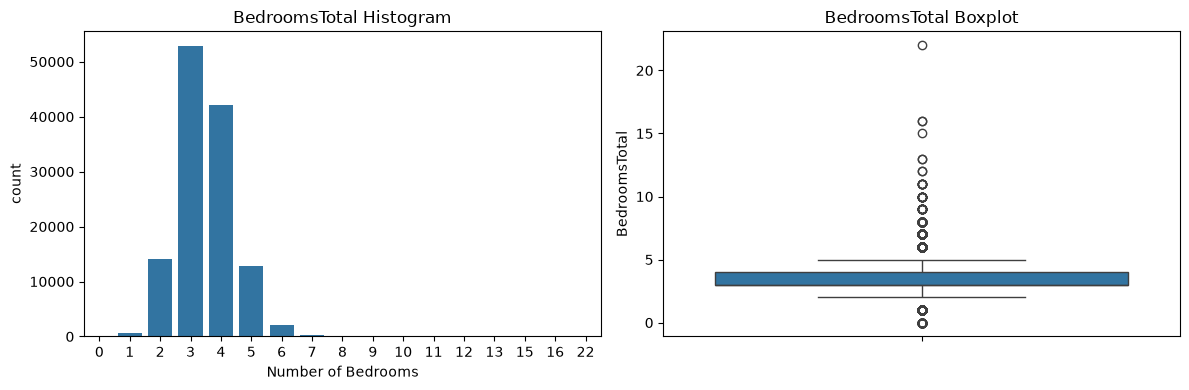

In [31]:
# Bedrooms
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=df_filtered["BedroomsTotal"].dropna().astype(int), ax=axes[0])
axes[0].set_title("BedroomsTotal Histogram")
axes[0].set_xlabel("Number of Bedrooms")

sns.boxplot(df_filtered["BedroomsTotal"].dropna(), ax=axes[1])
axes[1].set_title("BedroomsTotal Boxplot")

plt.tight_layout()
plt.show()

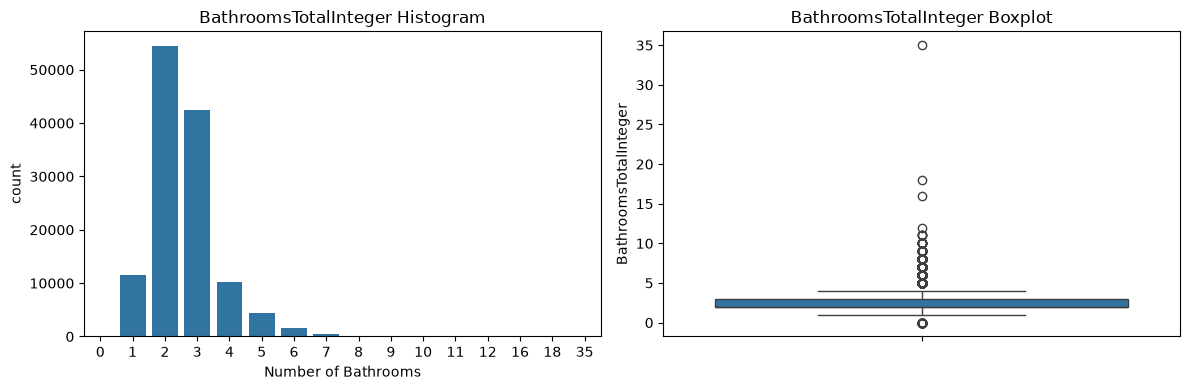

In [32]:
# Bathrooms
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=df_filtered["BathroomsTotalInteger"].dropna().astype(int), ax=axes[0])
axes[0].set_title("BathroomsTotalInteger Histogram")
axes[0].set_xlabel("Number of Bathrooms")

sns.boxplot(df_filtered["BathroomsTotalInteger"].dropna(), ax=axes[1])
axes[1].set_title("BathroomsTotalInteger Boxplot")

plt.tight_layout()
plt.show()

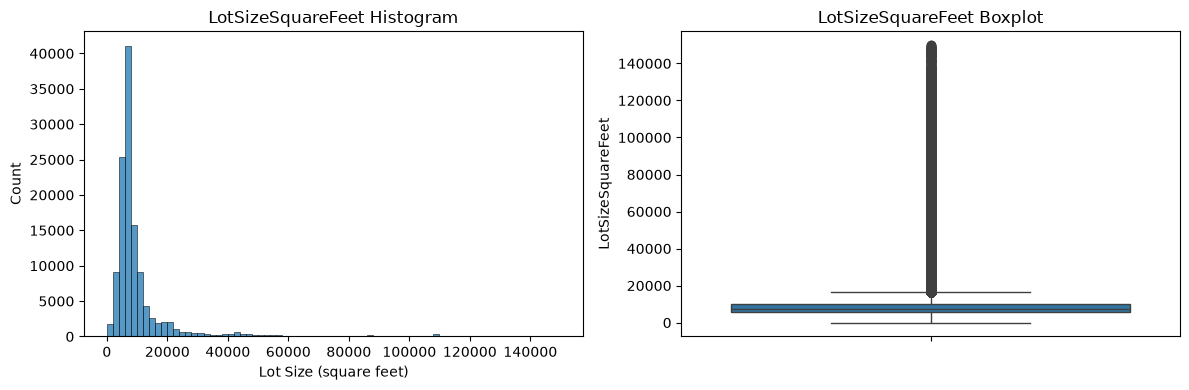

In [33]:
# LotSize
figs, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(x=df_filtered["LotSizeSquareFeet"].dropna(), bins=75, ax=axes[0])
axes[0].set_title("LotSizeSquareFeet Histogram")
axes[0].set_xlabel("Lot Size (square feet)")

sns.boxplot(df_filtered["LotSizeSquareFeet"].dropna(), ax=axes[1])
axes[1].set_title("LotSizeSquareFeet Boxplot")

plt.tight_layout()
plt.show()

Key Insights

All five variables appear right-skewed.
1. ClosePrice
    - Most properties were sold between 625K and 1415K, with a center at around 750K. 
    - There are also outliers that has close price well above 2.5M.
2. LivingArea
    - Most properties have a total livable area approximately between 1000 and 3000 square footage.
    - However, there are also outliers with a total livable area exceeding 4000 square footage, a threshold at which at least 95% of the observations lie below.
3. Bedrooms
    - Most properties have 2-5 bedrooms.
4. Bathrooms
    - Most properties have 1-4 bathrooms.
5. LotSize
    - Most properties have a total lot size of approxiamtely between 4K and 12K square footage.
    - There are also outliers with a total lot size well exceeding 20K square footage.